In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

TOXIC_COLOR = '#E2AB4A'
SAFE_COLOR = '#639922'

print("imports OK")

imports OK


In [4]:
df = pd.read_csv("../data/raw/youtoxic_english_1000.csv")

print(f"Shape of the dataset: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape of the dataset: (1000, 15)
Columns: ['CommentId', 'VideoId', 'Text', 'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']


In [5]:
df = df[["Text", "IsToxic"]].copy()

df["IsToxic"] = df["IsToxic"].astype(int)

df.head()

,Text,IsToxic
0,If only people would just take a step back and...,0
1,Law enforcement is not trained to shoot to app...,1
2,\nDont you reckon them 'black lives matter' ba...,1
3,There are a very large number of people who do...,0
4,"The Arab dude is absolutely right, he should h...",0


In [6]:
print("=== NULL ===")
print(df.isnull().sum())

print()
print("\n=== DUPLICATES ===")
n_duplicates = df["Text"].duplicated().sum()
print(f"Number of duplicate comments: {n_duplicates}")

if n_duplicates > 0:
    print(df[df["Text"].duplicated(keep=False)][["Text", "IsToxic"]])

print()
print("\n=== SHORT COMMENTS (< 10 chars) ===")
short = df[df["Text"].str.len() < 10]
print(f"Number of short comments: {len(short)}")
print(short.to_string())

=== NULL ===
Text       0
IsToxic    0
dtype: int64


=== DUPLICATES ===
Number of duplicate comments: 3
              Text  IsToxic
592  RUN THEM OVER        1
642  run them over        1
657  run them over        1
677  run them over        1
699  RUN THEM OVER        1


=== SHORT COMMENTS (< 10 chars) ===
Number of short comments: 13
          Text  IsToxic
105     Wow!!!        0
303  on drugs*        0
433        wtf        0
516  Thank you        0
548  Vile cunt        1
627     Idiots        1
691     Idiotz        1
745   Respect!        0
788     Bravo!        0
840    dumb mf        1
845      GOOD         0
965   ignorant        0
989  Dats tuff        0


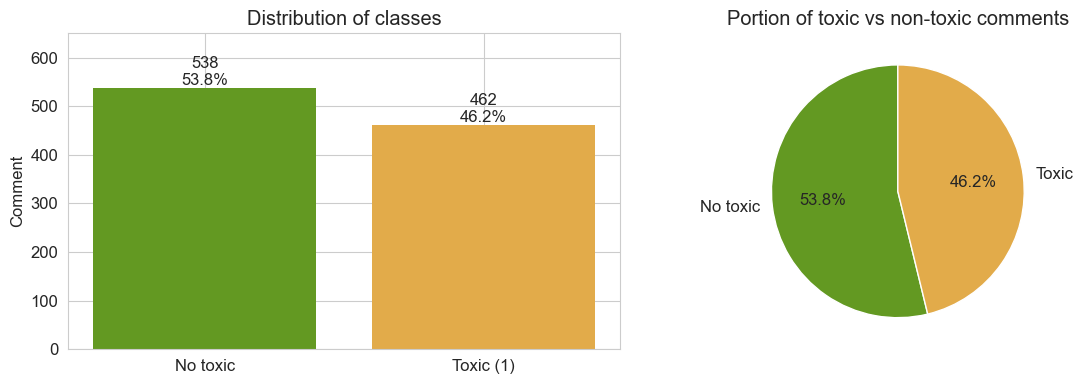

Ratio of majority to minority class: 1.16x


In [ ]:
counts = df["IsToxic"].value_counts()
pcts = df["IsToxic"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].bar(
    ["No toxic","Toxic (1)"],
    counts.values,
    color=[SAFE_COLOR,TOXIC_COLOR],
    edgecolor='none'
)

for i, (v, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, v + 5, f"{v}\n{p:.1f}%", ha="center", fontweight="500")
axes[0].set_title("Distribution of classes")
axes[0].set_ylabel("Comment")
axes[0].set_ylim(0,650)

axes[1].pie(
    counts.values,
    labels=["No toxic","Toxic"],
    colors=[SAFE_COLOR, TOXIC_COLOR],
    autopct="%1.1f%%",
    startangle=90
)

axes[1].set_title("Portion of toxic vs non-toxic comments")

plt.tight_layout()
plt.savefig("../reports/figures/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

ratio = counts.max() / counts.min()
print(f"Ratio of majority to minority class: {ratio:.2f}x")


In [ ]:
df["has_url"]               = df["Text"].str.contains(r"http://|www\.", regex=True)
df["has_mention"]           = df["Text"].str.contains(r"@\w+", regex=True)
df["has_number"]            = df["Text"].str.contains(r"\d+", regex=True)
df["has_caps"]              = df["Text"].str.contains(r"[A-Z]{3,}", regex=True)
df["has_repeated_chars"]    = df["Text"].str.contains(r"(.)\1{2,}", regex=True)

patterns_cols = ["has_url", "has_mention", "has_number", "has_caps", "has_repeated_chars"]

summary = pd.DataFrame({
    "Total":     df[patterns_cols].sum(),
    "Toxic":     df[df["IsToxic"] == 1][patterns_cols].sum(),
    "Non-Toxic": df[df["IsToxic"] == 0][patterns_cols].sum(),
})

print(summary)

                    Total  Toxic  Non-Toxic
has_url                11      1         10
has_mention             5      3          2
has_number            146     54         92
has_caps              187    103         84
has_repeated_chars    212     99        113


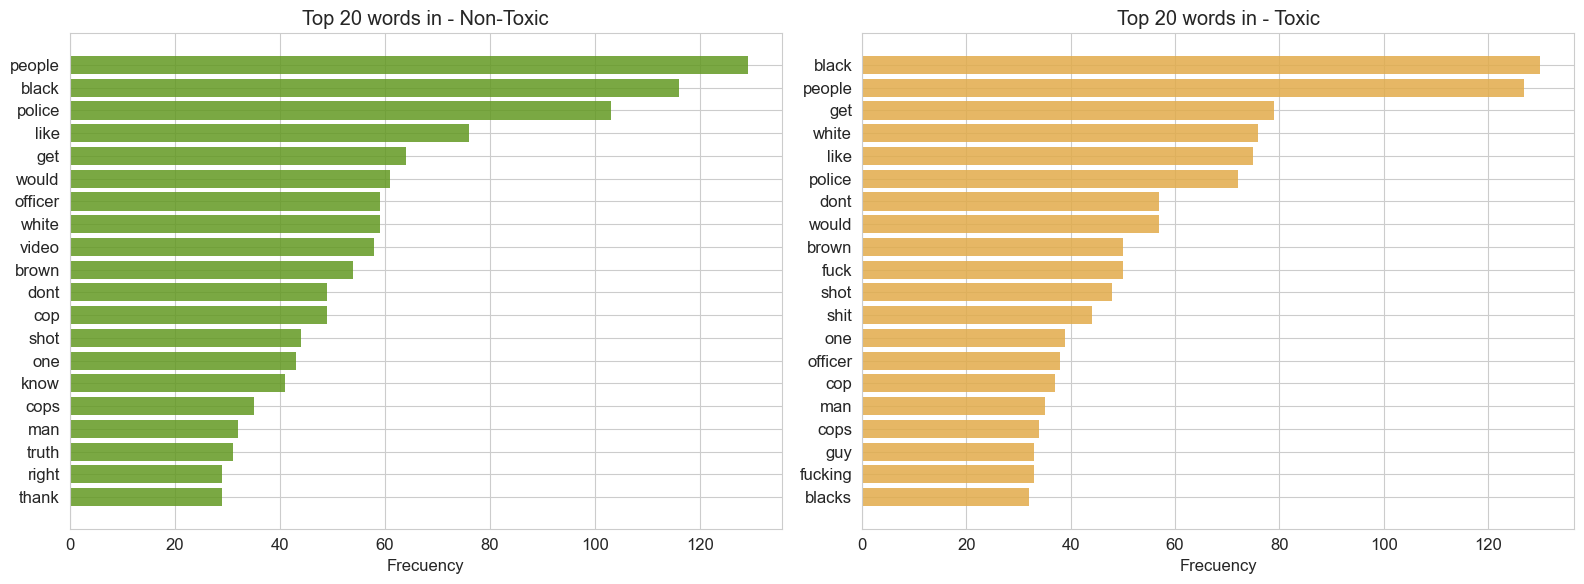

In [14]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def top_words(texts, n=20):
    words=[]
    for text in texts:
        cleaned = re.sub(r"https?://\S+|@\w+|[^a-zA-Z\s]", "", text).lower()
        tokens = [w for w in cleaned.split() if w not in STOP and len(w) > 2]
        words.extend(tokens)
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1,2,figsize=(16,6))

for ax, (label_val, label_name, color) in zip(axes, [
    (0, "Non-Toxic", SAFE_COLOR),
    (1, "Toxic", TOXIC_COLOR)
]):
    tw = top_words(df[df["IsToxic"] == label_val]["Text"])
    words, counts = zip(*tw)

    ax.barh(list(reversed(words)), list(reversed(counts)),
        color=color, alpha=0.85, edgecolor = "none")
    ax.set_title(f"Top 20 words in - {label_name}")
    ax.set_xlabel("Frecuency")

plt.tight_layout()
plt.savefig("../reports/figures/top_words.png", dpi=150, bbox_inches="tight")
plt.show()

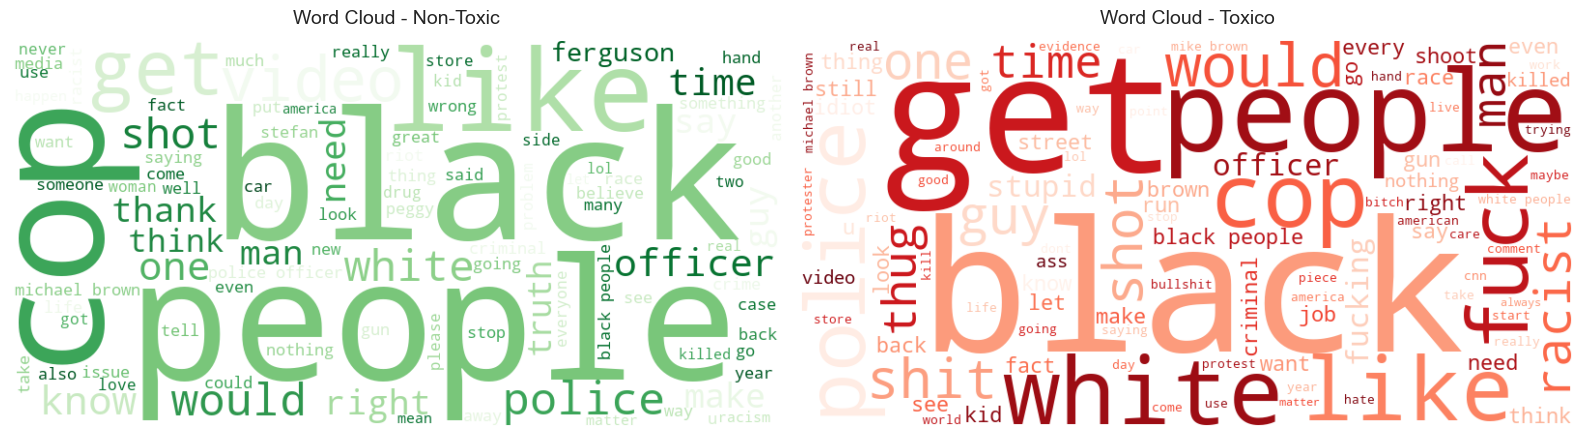

In [17]:
fig, axes = plt.subplots(1,2, figsize=(16,5))

for ax, (label_val, label_name, cmap) in zip(axes, [
    (0, "Non-Toxic", "Greens"),
    (1, "Toxico", "Reds")
]):
    corpus = " ".join(df[df["IsToxic"] == label_val]["Text"].str.lower())
    corpus = re.sub(r"https?://\S+|@\w+|[^a-zA-Z\s]", " ", corpus)

    wc = WordCloud(
        width=800, height=400,
        background_color="white",
        colormap= cmap,
        stopwords=STOP,
        max_words=100
    ).generate(corpus)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Word Cloud - {label_name}", fontsize=14, pad=12)

plt.tight_layout()
plt.savefig("../reports/figures/eda_04_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
import os  
os.makedirs("../data/processed", exist_ok=True)

df_clean = (df[["Text", "IsToxic"]]
                .drop_duplicates(subset="Text")
                .reset_index(drop=True)) 

df_clean.to_csv("../data/processed/youtoxic_clean.csv", index=False)

print(f"Original : {len(df)} filas")
print(f"Cleaned  : {len(df_clean)} filas")
print(f"Removed  : {len(df) - len(df_clean)} ducplicates")

Original : 1000 filas
Cleaned  : 997 filas
Removed  : 3 ducplicates
